# 🧘 Yoga Pose Detection using MediaPipe Pose Estimation and Artificial Neural Network (ANN)

## 📌 Problem Statement
Yoga practitioners often struggle to perform poses correctly without expert guidance. Incorrect posture can reduce the effectiveness of yoga and increase the risk of injury. This project develops an intelligent system that automatically detects and classifies yoga poses using MediaPipe Pose landmarks and an Artificial Neural Network (ANN).

## 🎯 Business Objective
- Develop an AI-based yoga pose detection system.
- Extract body landmarks using MediaPipe Pose.
- Classify yoga poses using an ANN model.
- Provide accurate real-time yoga pose prediction.
- Help users improve their yoga practice.

## ✅ Expected Output
The system predicts the correct yoga pose from the extracted body landmarks and displays the corresponding yoga pose name with high accuracy.

## 🎯 Target Variable (Y)
**Yoga Pose Label**

- Adho Mukha Svanasana
- Ardha Matsyendrasana
- Balasana
- Bhujangasana
- Chaturanga Dandasana
- Garudasana
- Natarajasana
- Ustrasana
- Utkatasana
- Utthita Trikonasana

## 📌 Input Features (X)
**MediaPipe Pose Landmarks**

- 33 body landmarks
- Each landmark contains:
  - X Coordinate
  - Y Coordinate
  - Z Coordinate (Depth)
  - Visibility Score

**Total Features = 33 × 4 = 132 numerical features**

kaggle link:https://www.kaggle.com/datasets/shrutisaxena/yoga-pose-image-classification-dataset

Import Libraries

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

 Set Dataset Path

In [ ]:
zip_path = "/content/dataset.zip"

Extract ZIP

In [ ]:
import zipfile

zip_path = "/content/dataset.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction Completed")

Set Correct Dataset Path

In [ ]:
os.listdir("/content/yoga_dataset")

['ardha uttanasana',
 'krounchasana',
 'pasasana',
 'marichyasana iii',
 'anantasana',
 'salamba bhujangasana',
 'vrischikasana',
 'makara adho mukha svanasana',
 'virabhadrasana iii',
 'sukhasana',
 'padmasana',
 'supta baddha konasana',
 'ashtanga namaskara',
 'parighasana',
 'parsva bakasana',
 'ardha matsyendrasana',
 'ananda balasana',
 'ardha pincha mayurasana',
 'natarajasana',
 'matsyasana',
 'vriksasana',
 'bhekasana',
 'prasarita padottanasana',
 'tulasana',
 'chaturanga dandasana',
 'parivrtta janu sirsasana',
 'vajrasana',
 'utthita trikonasana',
 'baddha konasana',
 'janu sirsasana',
 'virabhadrasana ii',
 'urdhva mukha svanasana',
 'bakasana',
 'tadasana',
 'hanumanasana',
 'bharadvajasana i',
 'balasana',
 'setu bandha sarvangasana',
 'simhasana',
 'urdhva prasarita eka padasana',
 'bhujangasana',
 'urdhva dhanurasana',
 'supta virasana',
 'garudasana',
 'camatkarasana',
 'anjaneyasana',
 'utthita hasta padangustasana',
 'lolasana',
 'virasana',
 'savasana',
 'halasana',

In [ ]:
import os

dataset_path = "/content/yoga_dataset"

classes = os.listdir(dataset_path)

print("Total folders/classes:", len(classes))
print(classes[:10])

In [ ]:
import os
import pandas as pd

dataset_path = "/content/yoga_dataset"

data = []

for pose in os.listdir(dataset_path):
    pose_path = os.path.join(dataset_path, pose)

    if os.path.isdir(pose_path):
        count = len(os.listdir(pose_path))
        data.append([pose, count])

df = pd.DataFrame(data, columns=["Pose", "Images"])

df = df.sort_values("Images", ascending=False)

df.head(20)

,Pose,Images
15,ardha matsyendrasana,90
24,chaturanga dandasana,90
67,bitilasana,87
62,ustrasana,87
43,garudasana,78
32,bakasana,77
69,vasisthasana,74
40,bhujangasana,73
55,utkatasana,73
53,astavakrasana,72


In [ ]:
selected_classes = [
    "adho mukha svanasana",
    "bhujangasana",
    "balasana",
    "utkatasana",
    "utthita trikonasana",
    "garudasana",
    "natarajasana",
    "chaturanga dandasana",
    "ustrasana",
    "ardha matsyendrasana"
]

Create filtered dataset folder

In [ ]:
import os
import shutil

source_path = "/content/yoga_dataset"
filtered_path = "/content/yoga_selected"

os.makedirs(filtered_path, exist_ok=True)

for pose in selected_classes:
    source_folder = os.path.join(source_path, pose)
    destination_folder = os.path.join(filtered_path, pose)

    if os.path.exists(source_folder):
        shutil.copytree(source_folder, destination_folder)
        print(pose, "copied")
    else:
        print(pose, "not found")

adho mukha svanasana copied
bhujangasana copied
balasana copied
utkatasana copied
utthita trikonasana copied
garudasana copied
natarajasana copied
chaturanga dandasana copied
ustrasana copied
ardha matsyendrasana copied


Verify

In [ ]:
classes = os.listdir(filtered_path)

print("Selected Classes:", len(classes))
print(classes)

Selected Classes: 10
['ardha matsyendrasana', 'natarajasana', 'chaturanga dandasana', 'utthita trikonasana', 'balasana', 'bhujangasana', 'garudasana', 'utkatasana', 'ustrasana', 'adho mukha svanasana']


Count images in final dataset

In [ ]:
import pandas as pd

data=[]

for pose in os.listdir(filtered_path):
    folder=os.path.join(filtered_path,pose)
    count=len(os.listdir(folder))
    data.append([pose,count])

df=pd.DataFrame(data,columns=["Pose","Images"])

df

,Pose,Images
0,ardha matsyendrasana,90
1,natarajasana,72
2,chaturanga dandasana,90
3,utthita trikonasana,69
4,balasana,71
5,bhujangasana,73
6,garudasana,78
7,utkatasana,73
8,ustrasana,87
9,adho mukha svanasana,69


In [ ]:
import mediapipe

print(mediapipe.__file__)
print(mediapipe.__version__)

/usr/local/lib/python3.12/dist-packages/mediapipe/__init__.py
1.0.0


In [ ]:
!pip uninstall mediapipe -y

Found existing installation: mediapipe 1.0.0
Uninstalling mediapipe-1.0.0:
  Successfully uninstalled mediapipe-1.0.0


In [ ]:
!pip install --upgrade protobuf==5.28.3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.6/316.6 kB 16.8 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 4.25.3
    Uninstalling protobuf-4.25.3:
      Successfully uninstalled protobuf-4.25.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mediapipe 0.10.21 requires protobuf<5,>=4.25.3, but you have protobuf 5.28.3 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 5.28.3 which is incompatible.


In [ ]:
import mediapipe as mp

print("MediaPipe:", mp.__version__)

mp_pose = mp.solutions.pose

pose = mp_pose.Pose(
    static_image_mode=True,
    model_complexity=1,
    min_detection_confidence=0.5
)

print("MediaPipe Pose Loaded Successfully")

MediaPipe: 0.10.21
MediaPipe Pose Loaded Successfully


Define Dataset Path

In [ ]:
dataset_path = "/content/yoga_selected"

Create Landmark Extraction Function

In [ ]:
import cv2
import os
import pandas as pd
import mediapipe as mp


mp_pose = mp.solutions.pose

pose = mp_pose.Pose(
    static_image_mode=True,
    model_complexity=1,
    min_detection_confidence=0.5
)


def extract_landmarks(image_path):

    image = cv2.imread(image_path)

    if image is None:
        return None

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    results = pose.process(image_rgb)

    if results.pose_landmarks:

        landmarks = []

        for lm in results.pose_landmarks.landmark:
            landmarks.extend([
                lm.x,
                lm.y,
                lm.z
            ])

        return landmarks

    return None

Extract All Images

In [ ]:
data = []

for pose_name in os.listdir(dataset_path):

    pose_folder = os.path.join(dataset_path, pose_name)

    if os.path.isdir(pose_folder):

        for img_name in os.listdir(pose_folder):

            img_path = os.path.join(
                pose_folder,
                img_name
            )

            landmarks = extract_landmarks(img_path)

            if landmarks:

                landmarks.append(pose_name)

                data.append(landmarks)


print("Images converted:", len(data))

Images converted: 723


Create DataFrame

In [ ]:
columns = [f"feature_{i}" for i in range(1,100)]
columns.append("label")

df = pd.DataFrame(
    data,
    columns=columns
)

df.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,...,feature_91,feature_92,feature_93,feature_94,feature_95,feature_96,feature_97,feature_98,feature_99,label
0,0.301924,0.175407,-0.154940,0.322841,0.141984,-0.165052,0.333247,0.140242,-0.164866,0.346337,...,0.928896,0.837196,-0.083934,0.493699,0.914368,-0.022093,1.141496,0.815680,-0.096011,ardha matsyendrasana
1,0.319889,0.157440,0.019628,0.343366,0.130037,0.001340,0.351559,0.129491,0.001282,0.359476,...,0.765005,0.899868,-0.300152,0.266886,0.993508,-0.380604,0.929809,0.920123,-0.429647,ardha matsyendrasana
2,0.524092,0.150791,-0.490097,0.558174,0.123849,-0.531977,0.569603,0.124258,-0.531668,0.583614,...,0.525496,0.859852,-0.024976,0.224009,0.866755,-0.169536,0.508123,0.962434,-0.021523,ardha matsyendrasana
3,0.216377,0.141119,-0.324946,0.238184,0.113991,-0.283342,0.251688,0.113328,-0.283809,0.264055,...,0.701891,0.816866,-1.069047,0.946056,0.766930,-1.469828,0.820469,0.735997,-1.325162,ardha matsyendrasana
4,0.777954,0.175001,-0.197866,0.754369,0.151193,-0.150024,0.753222,0.151359,-0.150134,0.751099,...,0.799816,0.851261,-0.028736,0.067210,0.847935,-0.309632,0.938095,0.927231,-0.123875,ardha matsyendrasana


Save CSV

In [ ]:
df.to_csv(
    "/content/yoga_landmarks.csv",
    index=False
)

print("Saved Successfully")

Saved Successfully


In [ ]:
dataset_path = "/content/yoga_selected"

Create landmark extraction function

In [ ]:
import cv2
import os
import pandas as pd
import mediapipe as mp


mp_pose = mp.solutions.pose

pose = mp_pose.Pose(
    static_image_mode=True,
    model_complexity=1,
    min_detection_confidence=0.5
)


def extract_landmarks(image_path):

    image = cv2.imread(image_path)

    if image is None:
        return None

    image_rgb = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    results = pose.process(image_rgb)

    if results.pose_landmarks:

        landmarks = []

        for lm in results.pose_landmarks.landmark:
            landmarks.extend([
                lm.x,
                lm.y,
                lm.z
            ])

        return landmarks

    return None

Extract all images

In [ ]:
data = []

for pose_name in os.listdir(dataset_path):

    pose_folder = os.path.join(dataset_path, pose_name)

    if os.path.isdir(pose_folder):

        for img_name in os.listdir(pose_folder):

            img_path = os.path.join(
                pose_folder,
                img_name
            )

            landmarks = extract_landmarks(img_path)

            if landmarks:
                landmarks.append(pose_name)
                data.append(landmarks)


print("Images converted:", len(data))

Images converted: 723


ANN Model Training

First load your CSV:

In [ ]:
import pandas as pd

df = pd.read_csv("/content/yoga_landmarks.csv")

df.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,...,feature_91,feature_92,feature_93,feature_94,feature_95,feature_96,feature_97,feature_98,feature_99,label
0,0.301924,0.175407,-0.154940,0.322841,0.141984,-0.165052,0.333247,0.140242,-0.164866,0.346337,...,0.928896,0.837196,-0.083934,0.493699,0.914368,-0.022093,1.141496,0.815680,-0.096011,ardha matsyendrasana
1,0.319889,0.157440,0.019628,0.343366,0.130037,0.001340,0.351559,0.129491,0.001282,0.359476,...,0.765005,0.899868,-0.300152,0.266886,0.993508,-0.380604,0.929809,0.920123,-0.429647,ardha matsyendrasana
2,0.524092,0.150791,-0.490097,0.558174,0.123849,-0.531977,0.569603,0.124258,-0.531668,0.583614,...,0.525496,0.859852,-0.024976,0.224009,0.866755,-0.169536,0.508123,0.962434,-0.021523,ardha matsyendrasana
3,0.216377,0.141119,-0.324946,0.238184,0.113991,-0.283342,0.251688,0.113328,-0.283809,0.264055,...,0.701891,0.816866,-1.069047,0.946056,0.766930,-1.469828,0.820469,0.735997,-1.325162,ardha matsyendrasana
4,0.777954,0.175001,-0.197866,0.754369,0.151193,-0.150024,0.753222,0.151359,-0.150134,0.751099,...,0.799816,0.851261,-0.028736,0.067210,0.847935,-0.309632,0.938095,0.927231,-0.123875,ardha matsyendrasana


Check dataset

In [ ]:
df.shape

(723, 100)

Check classes:

In [ ]:
df["label"].value_counts()

,count
label,
ardha matsyendrasana,87
chaturanga dandasana,87
ustrasana,75
garudasana,74
bhujangasana,70
utthita trikonasana,69
natarajasana,68
adho mukha svanasana,68
utkatasana,63


Separate Features and Target

In [ ]:
X = df.drop("label", axis=1)
y = df["label"]

Label Encoding

ANN needs numerical labels.

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

print(y_encoded[:10])
print(encoder.classes_)

[1 1 1 1 1 1 1 1 1 1]
['adho mukha svanasana' 'ardha matsyendrasana' 'balasana' 'bhujangasana'
 'chaturanga dandasana' 'garudasana' 'natarajasana' 'ustrasana'
 'utkatasana' 'utthita trikonasana']


Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(X_train.shape)
print(X_test.shape)

(578, 99)
(145, 99)


Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

Import TensorFlow/Keras

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

Build ANN Architecture

In [ ]:
model = Sequential()

# Input + Hidden Layer 1
model.add(Dense(
    128,
    activation="relu",
    input_shape=(99,)
))

# Dropout
model.add(Dropout(0.3))

# Hidden Layer 2
model.add(Dense(
    64,
    activation="relu"
))

# Output Layer
model.add(Dense(
    10,
    activation="softmax"
))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compile Model

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Check Model Summary

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        12,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,706 (84.79 KB)

 Trainable params: 21,706 (84.79 KB)

 Non-trainable params: 0 (0.00 B)

Train ANN

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=16
)

Epoch 1/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.3997 - loss: 1.8162 - val_accuracy: 0.7862 - val_loss: 1.1144
Epoch 2/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.7855 - loss: 0.8864 - val_accuracy: 0.8690 - val_loss: 0.6315
Epoch 3/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8529 - loss: 0.5408 - val_accuracy: 0.9103 - val_loss: 0.4671
Epoch 4/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8893 - loss: 0.3915 - val_accuracy: 0.9103 - val_loss: 0.4082
Epoch 5/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9152 - loss: 0.3108 - val_accuracy: 0.9241 - val_loss: 0.3644
Epoch 6/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9308 - loss: 0.2615 - val_accuracy: 0.9310 - val_loss: 0.3630
Epoch 7/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9533 - loss: 0.2000 - val_accuracy: 0.9310 - val_loss: 0.3537
Epoch 8/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9446 - loss: 0.1948 - val_accuracy: 0.9241 - val_los

Plot Accuracy and Loss Graphs

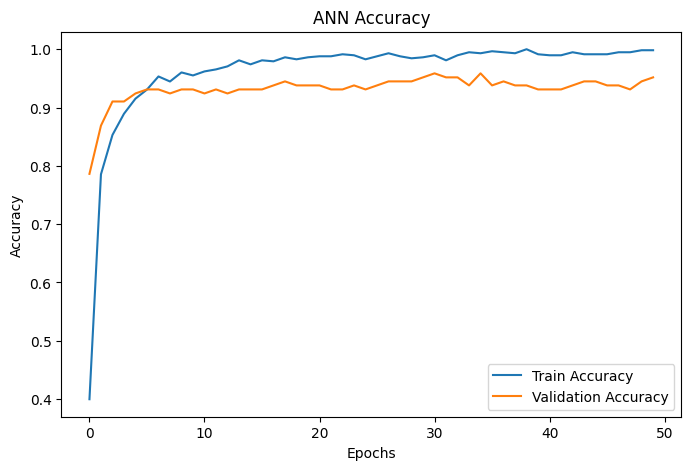

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("ANN Accuracy")
plt.legend()
plt.show()

Loss graph:

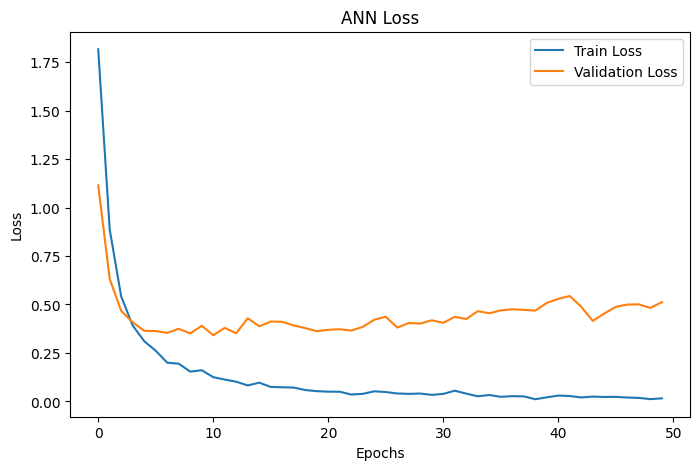

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("ANN Loss")
plt.legend()
plt.show()

Classification Report

In [ ]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

y_pred_classes = y_pred.argmax(axis=1)

print(classification_report(
    y_test,
    y_pred_classes,
    target_names=encoder.classes_
))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
                      precision    recall  f1-score   support

adho mukha svanasana       0.93      1.00      0.97        14
ardha matsyendrasana       0.94      1.00      0.97        17
            balasana       1.00      0.92      0.96        12
        bhujangasana       0.93      1.00      0.97        14
chaturanga dandasana       0.94      0.94      0.94        17
          garudasana       1.00      0.93      0.97        15
        natarajasana       1.00      1.00      1.00        14
           ustrasana       1.00      0.87      0.93        15
          utkatasana       1.00      0.85      0.92        13
 utthita trikonasana       0.82      1.00      0.90        14

            accuracy                           0.95       145
           macro avg       0.96      0.95      0.95       145
        weighted avg       0.96      0.95      0.95       145



Confusion Matrix

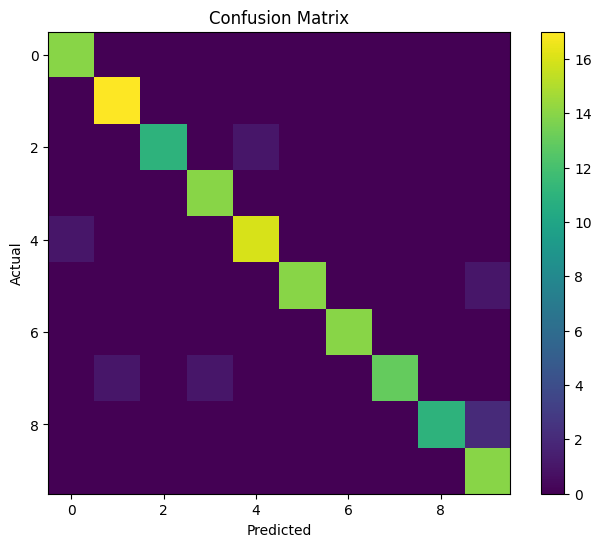

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred_classes
)

plt.figure(figsize=(8,6))
plt.imshow(cm)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()

In [ ]:
import joblib

# Save ANN model
model.save("/content/yoga_ann_model.keras")

# Save scaler
joblib.dump(
    scaler,
    "/content/scaler.pkl"
)

# Save label encoder
joblib.dump(
    encoder,
    "/content/label_encoder.pkl"
)

print("All files saved successfully")

All files saved successfully
